In [1]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')

# Keep only needed columns
df = df[['Text', 'Message']]

# Rename columns
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df.shape

(5572, 2)

In [3]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
df['length'] = df['message'].apply(len)

df['length'].mean()

np.float64(80.36468054558507)

In [5]:
from collections import Counter
import re

all_words = []

for msg in df['message']:
    words = re.findall(r'\b\w+\b', msg.lower())
    all_words.extend(words)

word_counts = Counter(all_words)

In [7]:
%pip install -U spacy
%pip install -U en_core_web_sm

import spacy

try:
	nlp = spacy.load("en_core_web_sm")
except OSError:
	import subprocess, sys
	subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
	nlp = spacy.load("en_core_web_sm")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement en_core_web_sm (from versions: none)
ERROR: No matching distribution found for en_core_web_sm

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [8]:
import re

def preprocess(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation & special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Process with spaCy
    doc = nlp(text)
    
    cleaned_tokens = []
    
    for token in doc:
        if not token.is_stop and not token.is_space:
            cleaned_tokens.append(token.lemma_)
    
    return " ".join(cleaned_tokens)

In [9]:
df['cleaned'] = df['message'].apply(preprocess)

df[['message', 'cleaned']].head()

,message,cleaned
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun early hor u c
4,"Nah I don't think he goes to usf, he lives aro...",nah not think go usf live


In [10]:
from sklearn.model_selection import train_test_split

X = df['cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
print("BoW features:", X_train_bow.shape)
print("TF-IDF features:", X_train_tfidf.shape)

BoW features: (4457, 6330)
TF-IDF features: (4457, 6330)


In [14]:
import numpy as np

def sparsity(matrix):
    return 1.0 - (matrix.count_nonzero() / (matrix.shape[0] * matrix.shape[1]))

print("BoW sparsity:", sparsity(X_train_bow))
print("TF-IDF sparsity:", sparsity(X_train_tfidf))

BoW sparsity: 0.9988832377916272
TF-IDF sparsity: 0.9988832377916272


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()

In [16]:
model.fit(X_train_bow, y_train)
y_pred_bow = model.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))

BoW Accuracy: 0.97847533632287


In [ ]:
model.fit(X_train_tfidf, y_train)
y_pred_tfidf = model.predict(X_test_tfidf)

print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))

TF-IDF Accuracy: 0.9515695067264573


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test_tfidf)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9515695067264573


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[962   3]
 [ 51  99]]


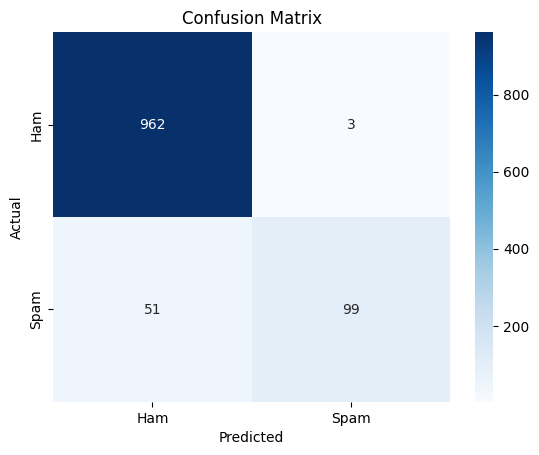

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()